# 4 — Regresión Ridge

📓 [Notebook de clase](../raw/4_regresion_lineal_regularizacion_ridge.ipynb) · ✏️ [Ejercicios](../exercises/4_regresion_lineal_regularizacion_ridge.ipynb) · 📕 *ESL* (Hastie, Tibshirani & Friedman) como referencia principal

> **TL;DR**
>
> - Ridge es cuadrados mínimos con un peaje: minimiza
>   $\|\textbf{y} - \textbf{X}\beta\|^2 + \lambda\|\beta\|^2$. El hiperparámetro
>   $\lambda \ge 0$ decide cuánto pesa el peaje: con $\lambda = 0$ recuperás OLS,
>   y a medida que $\lambda$ crece los coeficientes se van achicando hacia cero
>   (nunca llegan exactamente a cero).
> - La solución sigue siendo cerrada:
>   $\hat\beta^{ridge} = (\textbf{X}^T\textbf{X} + \lambda I)^{-1}\textbf{X}^T\textbf{y}$.
>   Y acá está el punto: **esa matriz es invertible para todo $\lambda > 0$**,
>   aunque $\textbf{X}$ no tenga rango completo. Ese es el problema de
>   multicolinealidad resuelto de raíz, no parcheado.
> - El precio es la **escala**: la penalización $\sum_j \beta_j^2$ no es
>   invariante ante cambios de unidades. Sin estandarizar los predictores, la
>   fórmula que escribe la clase no significa lo que parece. Y el intercepto
>   $\beta_0$ **no se penaliza**.
> - Vista con la SVD, la cuenta se vuelve transparente: OLS multiplica cada
>   dirección por $1/d_j$ y ridge por $d_j/(d_j^2+\lambda)$. El cociente entre
>   las dos es el **factor de encogimiento** $d_j^2/(d_j^2+\lambda) \le 1$, que
>   castiga muchísimo más a las direcciones con $d_j$ chico —justo las
>   inestables— y casi no toca a las de $d_j$ grande.
> - Ridge es un estimador **sesgado a propósito**. Gauss–Markov dice que OLS es
>   el mejor estimador lineal *insesgado*; ridge se sale de esa clase y compra
>   una reducción grande de varianza a cambio de un sesgo chico.

## 🗺️ Mapa de la clase

| Bloque de la clase | Celdas | Dónde lo explico |
|--------------------|--------|------------------|
| Regresión Lineal › Bibliografía: | 0 | §0 |
| Repaso | 1–2 | §1 |
| Repaso › Máxima verosimilitud › SVD | 3–4 | §1 (celda 3) · §2 (celda 4) |
| Métodos de regularización | 5 | §2 |
| Regresión Ridge | 6–10 | §3 (celdas 6–7) · §4 (celdas 8–9) · §5 (celda 10) |
| Única variable predictora | 11–15 | §5 |
| Dos variables predictoras | 16–21 | §6 |
| Estimadores | 22–27 | §7 |
| Regresión Ridge | 28–32 | §8 |
| Ejercicios | 33 | 🎯 Centros para los ejercicios |

In [1]:
# Setup — estilo de gráficos (ver referencias/estilo_graficos.md) + imports comunes
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## 0. Notación y convenciones

📓 celda 0 · 📕 ESL §3.4 · 📘 Bishop §3.1.4

La clase arranca con la portada bibliográfica y de ahí en más mete tres símbolos
nuevos. Fijémoslos antes de usarlos, porque dos de ellos cambian de nombre según
dónde los leas.

**$\lambda$ (lambda): el nivel de regularización.** Es un número no negativo que
vos elegís —no sale de los datos como $\beta$—. Por eso se le dice
**hiperparámetro** y no parámetro. Controla cuánto pesa el castigo a los
coeficientes grandes: $\lambda = 0$ es cuadrados mínimos de toda la vida,
$\lambda \to \infty$ aplasta todos los coeficientes contra el cero.

**$\hat\beta^{ridge}$ (leelo "beta sombrero ridge"): el vector de coeficientes
estimados con la penalización puesta.** El supraíndice no es una potencia: es una
etiqueta que lo distingue de $\hat\beta^{ols}$, el estimador de cuadrados mínimos.
Ambos son estimaciones del mismo $\beta$ verdadero, que nunca vas a conocer.

**$I$: la matriz identidad** de $p \times p$, unos en la diagonal y ceros afuera.
Aparece en $(\textbf{X}^T\textbf{X} + \lambda I)$ y su único trabajo ahí es
sumarle $\lambda$ a cada elemento de la diagonal de $\textbf{X}^T\textbf{X}$.

**El choque de nombres que te va a morder.** La clase escribe $\lambda$ en la
teoría y `alpha` en el código, porque `sklearn` llama `alpha` al mismo número.
Son lo mismo, siempre que la función de costo esté escrita igual. Y ahí está la
trampa fina, que vas a ver en la celda 19 de la clase: si el error lo escribís
como **promedio** ($\frac{1}{N}\sum$) pero la penalización como **suma**
($\sum_j \beta_j^2$), el $\lambda$ efectivo queda multiplicado por $N$. Dos
implementaciones con el mismo `alpha` pueden estar regularizando cantidades muy
distintas. Chequeá siempre cómo está escrito el costo antes de comparar valores
de $\lambda$ entre implementaciones.

| Concepto | Clase / ESL | `sklearn` | 📘 Bishop |
|---|---|---|---|
| Coeficientes | $\beta$ | `coef_` | $\textbf{w}$ |
| Nivel de regularización | $\lambda$ | `alpha` | $\lambda$ |
| Costo penalizado | $RSS(\beta) + \lambda\|\beta\|^2$ | ídem | *weight decay* / *shrinkage* |

**Los valores singulares $d_j$** ya los conocés de la clase 3: son los elementos
de la diagonal de $D$ en $\textbf{X} = U D V^T$, ordenados de mayor a menor. Los
vamos a reencontrar en §8, que es donde ridge se entiende de verdad.

**Los papers de la portada.** La clase lista tres, y vale saber qué aporta cada
uno: Hoerl & Kennard (1970) es donde nace ridge, Tibshirani (1996) introduce el
Lasso (la misma idea con $\sum_j |\beta_j|$ en vez de $\sum_j \beta_j^2$) y
Zou & Hastie (2005) proponen Elastic Net, que combina ambas penalizaciones. Esta
clase cubre solo la primera; las otras dos están en 📕 ESL §3.4 si querés tirar
del hilo.

## 1. Repaso: tres caminos que llegan al mismo $\hat\beta$

📓 celdas 1–3 · 📕 ESL §3.2 · 📘 Bishop §3.1

### La idea en criollo

Las primeras tres celdas de la clase son un repaso, pero no un repaso inocente.
Son tres rutas distintas para llegar al mismo estimador: cuadrados mínimos,
máxima verosimilitud y la SVD. Como tres mapas de la misma ciudad dibujados por
tres cartógrafos distintos: el destino es el mismo punto, lo que cambia es qué
calles decide mostrarte cada uno.

> **Dónde se rompe la analogía.** Tres mapas de la misma ciudad son
> intercambiables: si uno se te moja, usás otro. Acá no. Cuando $\textbf{X}$
> pierde rango, dos de los tres mapas dejan de servir —la fórmula con
> $(\textbf{X}^T\textbf{X})^{-1}$ ni siquiera está definida— y el de la SVD
> sigue funcionando vía la pseudoinversa. Que los tres coincidan es un lujo del
> caso bien portado, no una propiedad garantizada. Y la clase entera nace de
> preguntarse qué hacer cuando ese lujo se termina.

### Formalizándolo

**El modelo (celda 1).** Se asume que la relación entre el vector de entradas
$X^T = (X_1, \dots, X_p)$ y la salida $Y$ se aproxima bien con una función
lineal en los parámetros:

$$f(X) = \beta_0 + \sum_{j=1}^{p} X_j\beta_j = X^T\beta$$

donde en la forma compacta $X$ lleva un 1 en la primera posición, para que el
producto $X^T\beta$ absorba el intercepto $\beta_0$.

**Cuadrados mínimos (celda 2).** Se elige $\beta$ minimizando la suma de
residuos al cuadrado, y si $\textbf{X}$ tiene rango columna completo la solución
es la ecuación normal:

$$RSS(\beta) = \|\textbf{y} - \textbf{X}\beta\|^2, \qquad \hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$$

La derivación completa —abrir el binomio, derivar la cuadrática, verificar con
la segunda derivada que el punto crítico es un mínimo— está en la clase 2 §3.
Acá se da por sabida.

**Máxima verosimilitud (celda 3).** Si además suponés que los errores son
independientes, idénticamente distribuidos y normales con media cero y varianza
$\sigma^2$, maximizar la verosimilitud devuelve **exactamente el mismo**
$\hat\beta$. No es un método nuevo: es la misma cuenta con otro vestido. Lo que
sí agrega es un estimador de $\sigma^2$ y un marco probabilístico. Está
desarrollado en la clase 3 §2.

**SVD (celda 3).** Si $\textbf{X} = U D V^T$ con $U$ de $N \times p$ de columnas
ortonormales, $D$ diagonal de $p \times p$ y $V$ ortogonal de $p \times p$,
entonces la ecuación normal se reescribe. Vale la pena hacer la cuenta completa,
porque es exactamente el molde que vamos a reusar en §8 para ridge:

$$\textbf{X}^T\textbf{X} = (UDV^T)^T(UDV^T) = V D U^T U D V^T = V D^2 V^T$$

(usamos $U^TU = I$ porque las columnas de $U$ son ortonormales, y que $D$ es
diagonal, así que $DD = D^2$). Invertimos, aprovechando que $V$ es ortogonal
—$V^{-1} = V^T$— y que la inversa de un producto da vuelta el orden:

$$(\textbf{X}^T\textbf{X})^{-1} = (V D^2 V^T)^{-1} = V D^{-2} V^T$$

Y ahora armamos el estimador:

$$\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y} = V D^{-2} V^T \cdot V D U^T \textbf{y} = V D^{-2} D U^T\textbf{y} = V D^{-1} U^T \textbf{y}$$

donde en el anteúltimo paso cancelamos $V^TV = I$. Ese es el
$\hat\beta = V D^{-1} U^T \textbf{y}$ que escribe la clase.

**El detalle del rango.** Todo esto pide que ningún $d_j$ sea cero, porque
$D^{-1}$ tiene $1/d_j$ en la diagonal. Cuando algún $d_j = 0$ se reemplaza
$D^{-1}$ por la **pseudoinversa** $D^{+}$: se invierten solo los valores
singulares no nulos y los ceros se dejan en cero. Eso devuelve *una* solución
—la de norma mínima entre todas las que minimizan $RSS$—, no *la* solución,
porque cuando el rango no es completo hay infinitas.

### ¿Por qué nos importa?

Porque la tercera forma es la única que deja ver la maquinaria. En
$\hat\beta = V D^{-1} U^T\textbf{y}$ está escrito, término a término, que el
estimador **divide por los valores singulares**. Dividir por un número chico
amplifica. Toda la clase de hoy es una respuesta a esa división.

In [2]:
# Las tres rutas de la celda 3, sobre datos bien portados: tienen que coincidir.
rng = np.random.default_rng(0)
n, p = 200, 3
X = rng.normal(size=(n, p))
beta_real = np.array([2.0, -1.0, 0.5])
y = X @ beta_real + rng.normal(scale=0.5, size=n)

# Ecuación normal. Se resuelve el sistema, no se invierte la matriz (clase 2 §3).
beta_normal = np.linalg.solve(X.T @ X, X.T @ y)

# Vía SVD. Ojo: numpy devuelve V TRANSPUESTA, por eso el .T al usarla.
U, D, Vt = np.linalg.svd(X, full_matrices=False)
beta_svd = Vt.T @ np.diag(1 / D) @ U.T @ y

print("ecuación normal :", np.round(beta_normal, 4))
print("vía SVD         :", np.round(beta_svd, 4))
print("¿coinciden?     :", np.allclose(beta_normal, beta_svd))
print()
print("valores singulares d_j de X      :", np.round(D, 4))
print("raíz de los autovalores de X^T X :", np.round(np.sqrt(np.linalg.eigvalsh(X.T @ X))[::-1], 4))

ecuación normal : [ 1.9562 -1.0488  0.5275]
vía SVD         : [ 1.9562 -1.0488  0.5275]
¿coinciden?     : True

valores singulares d_j de X      : [14.7703 14.1996 13.2931]
raíz de los autovalores de X^T X : [14.7703 14.1996 13.2931]


Las dos rutas dan el mismo vector hasta la precisión de la máquina, y la última
línea confirma la relación de la clase 3: los valores singulares de $\textbf{X}$
son la raíz cuadrada de los autovalores de $\textbf{X}^T\textbf{X}$ (`eigvalsh`
los devuelve de menor a mayor, por eso el `[::-1]` para alinearlos con $D$, que
viene de mayor a menor).

### ⚠️ Confusión típica

`np.linalg.svd` **no** devuelve $V$: devuelve $V^T$. Si escribís
`V, D, U = np.linalg.svd(X)` y después usás `V` como si fuera la $V$ de la
fórmula, te vas a comer una transpuesta de más y los números van a dar cualquier
cosa —sin que nada tire error, porque las dimensiones cierran igual cuando la
matriz es cuadrada—. La convención segura es nombrarla `Vh` o `Vt`, como hace la
clase en la celda 25, y acordarte de poner el `.T` al usarla.

## 2. Cuando el rango se cae: multicolinealidad

📓 celdas 4–5 · 📕 ESL §3.4 · 📘 Bishop §3.1.4

### La idea en criollo

Tenés dos testigos de un accidente que declararon casi lo mismo. Sabés que entre
los dos aportaron cierta cantidad de información, pero no tenés forma de decidir
cuánto mérito le corresponde a cada uno: si le sacás crédito a uno y se lo das
al otro, el relato conjunto no cambia en nada. La cuenta total está firme; el
reparto es indeterminado.

> **Dónde se rompe la analogía.** Con los testigos no hay un número que mida
> "cuánto de indeterminado" es el reparto, y acá sí lo hay, y muy preciso: el
> valor singular más chico, $d_{min}$. Además, en el caso extremo de dos
> predictores idénticos, lo que queda perfectamente determinado no es una
> vaguedad —es exactamente la **suma** $\beta_1 + \beta_2$—. Ese es, palabra por
> palabra, el ejercicio 3 de esta clase.

### Formalizándolo

La celda 4 tira dos preguntas y sigue de largo: *¿qué pasa si $\textbf{X}$ no
tiene rango completo?* y *¿qué pasa si hay predictores correlacionados o
multicolinealidad?*. Son la misma pregunta en dos intensidades.

**Rango incompleto (el caso exacto).** Alguna columna de $\textbf{X}$ es
combinación lineal de las otras. Entonces existe un $v \neq 0$ con
$\textbf{X}v = 0$, y eso implica dos cosas encadenadas:

$$\textbf{X}^T\textbf{X}v = \textbf{X}^T 0 = 0 \implies \textbf{X}^T\textbf{X} \text{ tiene autovalor } 0 \implies \text{es singular}$$

La inversa no existe y no hay un único $\hat\beta$: si $\hat\beta$ minimiza
$RSS$, entonces $\hat\beta + cv$ también lo hace para **cualquier** $c$, porque
$\textbf{X}(\hat\beta + cv) = \textbf{X}\hat\beta$ da exactamente las mismas
predicciones. Hay una recta entera (o un subespacio entero) de soluciones
igual de buenas.

**Multicolinealidad (el caso aproximado, que es el que pasa de verdad).** Ninguna
columna es exactamente combinación de las otras, pero casi. Entonces
$\textbf{X}^T\textbf{X}$ no es singular, es *casi* singular: su autovalor más
chico, $d_{min}^2$, es un número muy pequeño pero positivo. Acá está la
consecuencia, y sale directo de las dos fórmulas que ya tenemos:

$$Var(\hat\beta) = \sigma^2(\textbf{X}^T\textbf{X})^{-1} = \sigma^2 V D^{-2} V^T$$

Los elementos de $D^{-2}$ son $1/d_j^2$. Si $d_{min} = 0{,}01$, ese término vale
$10^4$: la varianza del estimador en esa dirección se multiplica por diez mil.
Traducido: cambiás un poco los datos y $\hat\beta$ pega un salto enorme.

El número que resume esto es el **número de condición**
$\kappa = d_{max}/d_{min}$. Cuanto más grande, más inestable es el problema.

### ¿Por qué nos importa?

Porque la celda 2 de la clase decía que cuadrados mínimos no pide "prácticamente
ninguna hipótesis sobre los datos, más allá de que $\textbf{X}$ tiene rango
completo". Esa hipótesis parecía un tecnicismo. No lo es: es la que se rompe
todo el tiempo en datos reales —variables que miden cosas parecidas, más
predictores que observaciones, categóricas codificadas de más— y cuando se
rompe, se rompe con todo.

In [3]:
# Dos predictores con correlación rho. ¿Cómo se degrada la estimación al subir rho?
# Ajusta OLS sobre 'reps' muestras del mismo modelo y mide cuánto varía beta.
def experimento(rho, n=100, reps=400, seed=0):
    rng = np.random.default_rng(seed)
    betas = []
    for _ in range(reps):
        x1 = rng.normal(size=n)
        x2 = rho * x1 + np.sqrt(1 - rho**2) * rng.normal(size=n)
        X = np.column_stack([x1, x2])
        y = 2 * x1 + 3 * x2 + rng.normal(size=n)      # beta real = (2, 3) siempre
        betas.append(np.linalg.solve(X.T @ X, X.T @ y))
    betas = np.array(betas)
    d = np.linalg.svd(X, compute_uv=False)            # última muestra, a modo de ejemplo
    return {"rho": rho, "d_min": d.min(), "kappa": d.max() / d.min(),
            "sd(b1)": betas[:, 0].std(), "sd(b2)": betas[:, 1].std()}

tabla = pd.DataFrame([experimento(r) for r in [0.0, 0.5, 0.9, 0.99, 0.999]])
print(tabla.round(3).to_string(index=False))

  rho  d_min  kappa  sd(b1)  sd(b2)
0.000  8.785  1.223   0.100   0.103
0.500  7.431  1.480   0.119   0.119
0.900  3.174  4.082   0.240   0.237
0.990  0.974 14.031   0.735   0.731
0.999  0.305 45.335   2.312   2.308


Leé la tabla de izquierda a derecha en la última fila: con $\rho = 0{,}999$ el
valor singular más chico cae a una fracción del de $\rho = 0$, el número de
condición se dispara, y el desvío de $\hat\beta_1$ pasa de ser decimal a ser del
orden del propio coeficiente. El modelo sigue ajustando bien —las predicciones
no se rompen—, pero los coeficientes dejaron de significar algo.

Veámoslo como nube de puntos, que es donde se entiende de dónde sale esa
varianza:

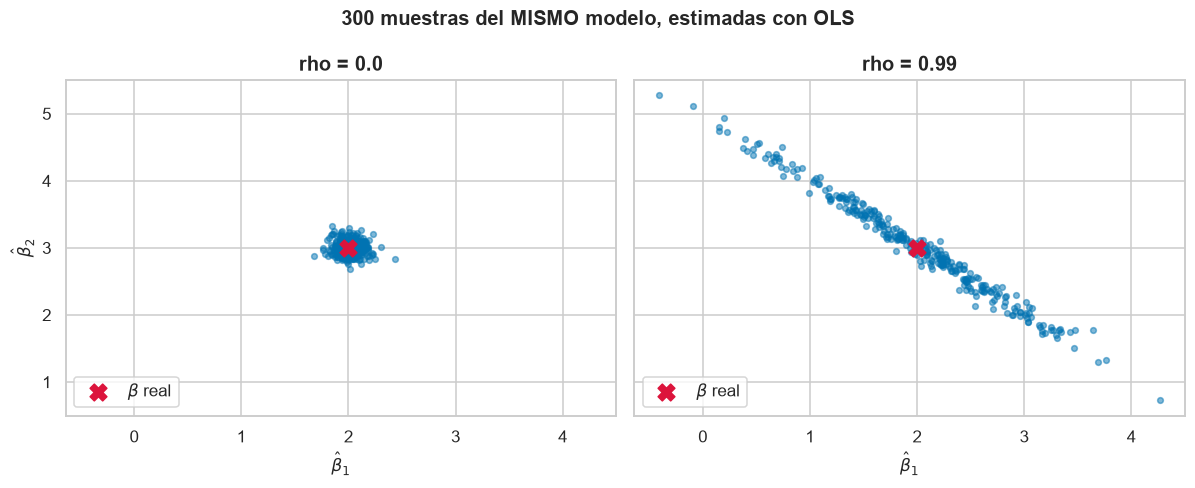

In [4]:
def nube_betas(rho, n=100, reps=300, seed=1):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(reps):
        x1 = rng.normal(size=n)
        x2 = rho * x1 + np.sqrt(1 - rho**2) * rng.normal(size=n)
        X = np.column_stack([x1, x2])
        y = 2 * x1 + 3 * x2 + rng.normal(size=n)
        out.append(np.linalg.solve(X.T @ X, X.T @ y))
    return np.array(out)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, rho in zip(axes, [0.0, 0.99]):
    b = nube_betas(rho)
    ax.scatter(b[:, 0], b[:, 1], s=14, alpha=0.5)
    ax.scatter(2, 3, color="crimson", s=120, marker="X", zorder=5, label=r"$\beta$ real")
    ax.set_title(f"rho = {rho}")
    ax.set_xlabel(r"$\hat\beta_1$")
    ax.legend(loc="lower left", frameon=True, facecolor="white")
axes[0].set_ylabel(r"$\hat\beta_2$")
fig.suptitle("300 muestras del MISMO modelo, estimadas con OLS", fontweight="bold")
plt.tight_layout()
plt.show()

A la izquierda, con predictores independientes, los 300 ajustes caen en una
pelotita apretada alrededor del $\beta$ verdadero. A la derecha, con $\rho$ casi
uno, la nube se estira en una diagonal larguísima de pendiente negativa: cada
muestra le da de más a un coeficiente y de menos al otro, compensando. Los dos
paneles comparten ejes, así que la comparación es directa.

Mirá la dirección en que se estira: es la recta $\beta_1 + \beta_2 \approx$
constante. **La suma está bien estimada; el reparto no.** Eso es literalmente lo
que dice la fórmula $Var(\hat\beta) = \sigma^2 V D^{-2} V^T$: la varianza
explota en la dirección del $d_j$ más chico, que acá es la dirección
$(1, -1)/\sqrt2$.

### ❓ La pregunta que quedó abierta

La celda 5 menciona una segunda motivación —**Gauss–Markov**— y la deja para más
adelante ("*probablemente veamos Gauss–Markov luego de ver compromiso
sesgo-varianza*"). El resumen de una línea, para que no te quede colgada: el
teorema dice que, entre todos los estimadores **lineales e insesgados**, OLS es
el de menor varianza. La palabra clave es *insesgados*. Ridge es sesgado, así
que ni compite en esa categoría — y justamente por salirse de la categoría puede
conseguir una varianza mucho menor. La prueba está en 📕 ESL §3.2.2 y el
compromiso sesgo–varianza en 📕 ESL §2.9 y §7.2.

### ⚠️ Confusión típica

Creer que la multicolinealidad arruina las **predicciones**. No es así: en el
panel de la derecha, cada uno de esos 300 modelos con coeficientes disparatados
predice bastante bien dentro del rango de los datos, porque los errores de
$\beta_1$ y $\beta_2$ se cancelan entre sí exactamente donde $x_1 \approx x_2$.
Lo que se rompe es la **interpretación** de cada coeficiente por separado, y la
**estabilidad** ante datos nuevos o extrapolación. Si tu objetivo es solo
predecir en el mismo régimen, la multicolinealidad molesta menos de lo que
parece; si querés leer los coeficientes, es fatal.

## 3. Ridge: la formulación y el rol de $\lambda$

📓 celdas 6–7 · 📕 ESL §3.4 · 📘 Bishop §3.1.4

### La idea en criollo

Cuadrados mínimos tiene un solo mandato: ajustá los datos lo mejor que puedas.
Con dos predictores casi idénticos, ese mandato lo cumple igual de bien un
$\hat\beta = (2, 3)$ que un $\hat\beta = (600, -595)$. Ridge le agrega un segundo
mandato que rompe el empate: *y además, no te vayas lejos del cero*. Es un peaje
que se cobra por coeficiente grande, y el que decide la tarifa sos vos, con
$\lambda$.

> **Dónde se rompe la analogía.** Un peaje real es plano: pagás lo mismo por
> pasar, y dos autos pagan el doble que uno. Este es **cuadrático**: duplicar un
> coeficiente cuadruplica lo que pagás por él. Por eso ridge castiga de manera
> desproporcionada a un coeficiente enorme y casi no le cobra a varios chicos —
> de ahí su costumbre de *repartir* el peso en vez de concentrarlo—. Y hay un
> vehículo exento: el intercepto $\beta_0$ no paga peaje.

### Formalizándolo

La clase escribe el mismo problema de tres maneras en la celda 6. Son la misma
cosa:

$$\hat\beta^{ridge} = \arg\min_{\beta}\{\|\textbf{y} - \textbf{X}\beta\|^2 + \lambda\|\beta\|^2\}$$

$$\hat\beta^{ridge} = \arg\min_{\beta}\{(\textbf{y} - \textbf{X}\beta)^T(\textbf{y} - \textbf{X}\beta) + \lambda\beta^T\beta\}$$

La primera y la segunda son idénticas: $\|v\|^2 = v^Tv$ para cualquier vector.
La tercera es la misma escrita con sumatorias, y es la que tiene la información
que las otras dos esconden:

$$\hat\beta^{ridge} = \arg\min_{\beta}\Big\{\sum_{i=1}^{N}\big(y_i - \beta_0 - \sum_{j=1}^{p}x_{ij}\beta_j\big)^2 + \lambda\sum_{j=1}^{p}\beta_j^2\Big\}$$

Fijate en el índice de la penalización: **arranca en $j=1$, no en $j=0$**. El
intercepto queda afuera. En las dos primeras formas eso no se ve, y por eso la
clase aclara que solo son correctas "*si los predictores fueron
estandarizados*" — con los datos centrados, el intercepto se desacopla del
resto y se puede sacar de la cuenta.

**El rol de $\lambda$ (celda 7).** Es el dial entre dos extremos:

- $\lambda = 0$: el segundo término desaparece y tenés cuadrados mínimos puro.
- $\lambda$ creciente: cada vez le cuesta más al optimizador tener coeficientes
  grandes, así que los va achicando. El ajuste empeora y el modelo se vuelve
  más rígido.
- $\lambda \to \infty$: la penalización domina y la única forma de que el costo
  no explote es $\beta \to 0$. El modelo predice la constante $\bar y$.

**Las dos preguntas de la celda 6.** La clase las tira y sigue. Van respondidas.

*¿Por qué conviene que los atributos estén centrados?* Porque centrar desacopla
el intercepto de todo lo demás. Si a cada columna le restás su media, la columna
de unos queda ortogonal a todas las otras, y entonces $\hat\beta_0 = \bar y$ sale
por separado, sin depender de los demás coeficientes ni de $\lambda$. Si no
centrás, el intercepto se mezcla con el resto y aparece un problema conceptual
feo: sin centrar, **la solución depende de dónde pusiste el origen de cada
variable**. Medir la temperatura en Celsius o en Kelvin —la misma variable
corrida en 273— te daría modelos distintos, lo cual no tiene ningún sentido. Por
eso el intercepto no se penaliza: es el que absorbe los corrimientos, y
castigarlo sería castigar el hecho de que la media de $y$ no sea cero.

*¿Por qué conviene que tengan todos la misma varianza?* Porque la penalización
$\sum_j \beta_j^2$ suma coeficientes que viven en unidades distintas, como si
sumaras pesos con metros. Si $x_1$ está en metros y lo pasás a kilómetros, su
coeficiente se multiplica por 1000 para compensar, y su aporte a la penalización
se multiplica por un millón. El mismo $\lambda$ pasa a castigar muchísimo a esa
variable, por una decisión de unidades que no tiene nada que ver con el
problema. Estandarizar —restar la media y dividir por el desvío— pone a todos
los coeficientes en la misma moneda y hace que $\lambda$ signifique lo mismo
para todos. A diferencia de OLS, que es **equivariante** ante cambios de escala
(reescalás una columna y el coeficiente se acomoda solo, sin cambiar las
predicciones), ridge **no** lo es.

### ¿Por qué nos importa?

Porque esto convierte al ajuste en una familia de modelos indexada por
$\lambda$, en vez de un modelo único. Ya no ajustás "el" modelo: recorrés un
camino que va desde OLS ($\lambda=0$) hasta el modelo nulo
($\lambda \to \infty$), y elegir dónde pararte es una decisión que los datos de
entrenamiento **no** pueden tomar por vos — porque el $\lambda$ que mejor ajusta
el entrenamiento es siempre $\lambda = 0$. Hace falta validación cruzada
(📕 ESL §7.10), y es justo lo que pregunta el ejercicio 2.

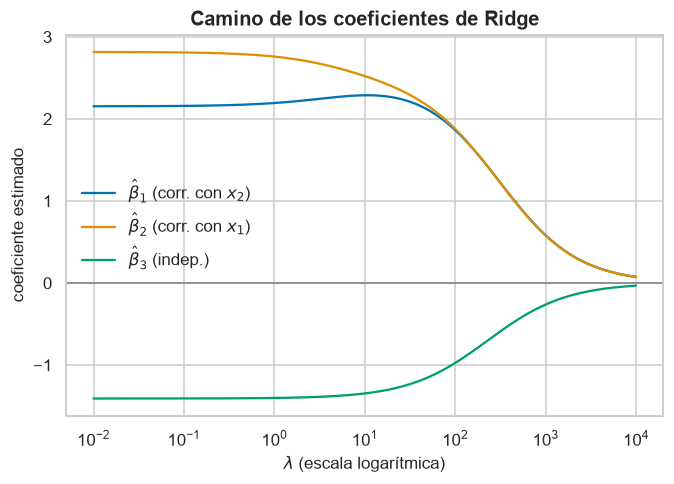

lambda = 0.01 : [ 2.154  2.815 -1.407]
lambda = 100  : [ 1.864  1.878 -0.974]
lambda = 10000: [ 0.074  0.073 -0.032]


In [5]:
# El camino de los coeficientes: cómo se achican a medida que lambda crece.
rng = np.random.default_rng(42)
n = 200
x1 = rng.normal(size=n)
x2 = 0.97 * x1 + np.sqrt(1 - 0.97**2) * rng.normal(size=n)   # muy correlacionado con x1
x3 = rng.normal(size=n)                                      # independiente
X = np.column_stack([x1, x2, x3])
y = 2 * x1 + 3 * x2 - 1.5 * x3 + rng.normal(scale=1.0, size=n)

def ridge(X, y, lam):
    # Resolvemos el sistema (X^T X + lambda I) beta = X^T y, sin invertir nada.
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

lams = np.logspace(-2, 4, 200)
camino = np.array([ridge(X, y, l) for l in lams])

fig, ax = plt.subplots()
for j, nombre in enumerate([r"$\hat\beta_1$ (corr. con $x_2$)", r"$\hat\beta_2$ (corr. con $x_1$)", r"$\hat\beta_3$ (indep.)"]):
    ax.plot(lams, camino[:, j], label=nombre)
ax.axhline(0, color="grey", lw=1)
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$ (escala logarítmica)")
ax.set_ylabel("coeficiente estimado")
ax.set_title("Camino de los coeficientes de Ridge")
ax.legend()
plt.show()

print("lambda = 0.01 :", np.round(ridge(X, y, 0.01), 3))
print("lambda = 100  :", np.round(ridge(X, y, 100), 3))
print("lambda = 10000:", np.round(ridge(X, y, 10000), 3))

Tres cosas para leer en ese gráfico:

1. A la izquierda (penalización casi nula) los coeficientes valen lo que vale
   OLS. A la derecha los tres van juntos hacia cero, pero **nunca lo tocan**:
   se acercan asintóticamente. Ridge encoge, no selecciona. El que sí pone
   coeficientes exactamente en cero es el Lasso (📕 ESL §3.4.2), que usa
   $\sum_j|\beta_j|$ en vez de $\sum_j\beta_j^2$.
2. Los dos coeficientes correlacionados **convergen a un valor común**: a partir
   de $\lambda \approx 100$ las dos curvas son indistinguibles. Ridge les repartió
   el peso en partes iguales, que es la propiedad que el ejercicio 3 te pide
   demostrar. El tercero no tiene con quién repartir, así que se limita a
   encogerse.
3. No hay ningún $\lambda$ marcado como "el correcto" en el gráfico, porque el
   gráfico no lo puede saber. Eso sale de validación cruzada.

Ahora la parte de la escala, que es la que arruina resultados en silencio:

In [6]:
# ¿Qué pasa si cambio las unidades de un predictor? Comparamos todo en la escala original.
X_km = np.column_stack([x1 / 1000, x2, x3])   # x1 pasa de "metros" a "kilómetros"
volver = np.array([1 / 1000, 1, 1])           # para devolver el coef. a la escala de x1

np.set_printoptions(precision=6, suppress=True)
print("OLS   con x1 original  :", ridge(X, y, 0.0).round(6))
print("OLS   con x1 en km     :", (ridge(X_km, y, 0.0) * volver).round(6), " <- idéntico")
print()
print("Ridge con x1 original  :", ridge(X, y, 50.0).round(6))
print("Ridge con x1 en km     :", (ridge(X_km, y, 50.0) * volver).round(6), " <- otro modelo")

OLS   con x1 original  : [ 2.153702  2.815818 -1.407545]
OLS   con x1 en km     : [ 2.153702  2.815818 -1.407545]  <- idéntico

Ridge con x1 original  : [ 2.110838  2.157952 -1.150029]
Ridge con x1 en km     : [ 0.000004  3.695228 -1.178974]  <- otro modelo


Con $\lambda = 0$ las dos filas coinciden hasta el último decimal: cuadrados
mínimos no se entera del cambio de unidades. Con $\lambda = 50$ dan modelos
completamente distintos, y fijate cómo: al achicar $x_1$ por mil, su coeficiente
necesita crecer por mil para compensar, y ridge —que cobra el cuadrado del
coeficiente— prefiere no pagar ese precio y lo aplasta casi hasta cero,
volcándole todo el trabajo a $x_2$. Nada cambió en los datos —la misma variable, medida en otra unidad—
y sin embargo el modelo cambió. Por eso estandarizar no es un paso opcional de
prolijidad: es parte de la definición del método.

### ⚠️ Confusión típica

Suponer que la librería estandariza por vos. `sklearn.linear_model.Ridge` **no**
estandariza: ajusta con las columnas tal cual se las pasás. Lo que sí hace por
defecto (`fit_intercept=True`) es centrar internamente para no penalizar el
intercepto. Si querés ridge bien hecho, el estandarizado es tuyo, y tiene que ir
adentro de un `Pipeline` con `StandardScaler` para que la media y el desvío se
calculen **solo con el conjunto de entrenamiento** de cada fold de validación
cruzada. Estandarizar todo el dataset antes de partirlo filtra información del
conjunto de test hacia el entrenamiento.

## 4. La solución cerrada: de dónde sale $(\textbf{X}^T\textbf{X} + \lambda I)^{-1}$

📓 celdas 8–9 · 📕 ESL §3.4

### La idea en criollo

La buena noticia es que agregar la penalización no nos hace perder el lujo de la
fórmula cerrada. Le sumamos al costo un término que también es cuadrático en
$\beta$, así que el costo total sigue siendo una cuadrática, y una cuadrática
sabemos minimizarla de una: derivar, igualar a cero, despejar. Sin iterar, sin
tasa de aprendizaje, sin mínimos locales.

### Formalizándolo

Partimos del costo de la celda 8:

$$RSS(\beta, \lambda) = (\textbf{y} - \textbf{X}\beta)^T(\textbf{y} - \textbf{X}\beta) + \lambda\beta^T\beta$$

El primer término ya lo abrimos en la clase 2:

$$RSS(\beta,\lambda) = \textbf{y}^T\textbf{y} - 2\,\textbf{y}^T\textbf{X}\beta + \beta^T\textbf{X}^T\textbf{X}\beta + \lambda\beta^T\beta$$

Derivamos respecto de $\beta$. Para el término nuevo usamos la misma regla que
para el cuadrático anterior, $\partial(\beta^TA\beta)/\partial\beta = 2A\beta$
con $A$ simétrica, tomando $A = \lambda I$ (que es simétrica, y más aún:
diagonal):

$$\frac{\partial RSS}{\partial\beta} = -2\textbf{X}^T\textbf{y} + 2\textbf{X}^T\textbf{X}\beta + 2\lambda\beta$$

Igualamos a cero y dividimos todo por 2:

$$\textbf{X}^T\textbf{X}\beta + \lambda\beta = \textbf{X}^T\textbf{y}$$

Sacamos $\beta$ de factor común por derecha. Acá hay un paso que parece trivial
y no lo es: $\beta$ no se puede factorizar directamente porque en el primer
término está multiplicado por una matriz y en el segundo por un escalar. El
truco es escribir $\lambda\beta = \lambda I \beta$, y recién ahí los dos
términos tienen la misma forma:

$$(\textbf{X}^T\textbf{X} + \lambda I)\,\hat\beta^{ridge} = \textbf{X}^T\textbf{y} \quad\Longrightarrow\quad \hat\beta^{ridge} = (\textbf{X}^T\textbf{X} + \lambda I)^{-1}\textbf{X}^T\textbf{y}$$

**Y falta el paso que la clase saltea**: derivada primera cero da un punto
crítico, no un mínimo. La derivada segunda es $2(\textbf{X}^T\textbf{X} + \lambda I)$.
Para cualquier vector $v \neq 0$:

$$v^T(\textbf{X}^T\textbf{X} + \lambda I)v = \|\textbf{X}v\|^2 + \lambda\|v\|^2 > 0 \quad \text{si } \lambda > 0$$

porque el primer sumando es $\ge 0$ siempre y el segundo es estrictamente
positivo. Entonces la matriz es **definida positiva**, el costo es estrictamente
convexo, y el punto crítico es el mínimo global **único**. Fijate que esto vale
sin pedirle nada a $\textbf{X}$: ni rango completo, ni $N > p$, nada.

**La respuesta a la celda 9.** La clase pregunta *"¿por qué aborda el problema de
la multicolinealidad?"* y no la contesta. La cuenta de arriba **es** la
respuesta, y se ve todavía mejor con autovalores. Vimos en §1 que
$\textbf{X}^T\textbf{X} = VD^2V^T$, o sea que sus autovalores son los $d_j^2 \ge 0$.
Sumarle $\lambda I$ no toca los autovectores y le suma $\lambda$ a cada
autovalor:

$$\text{autovalores de } (\textbf{X}^T\textbf{X} + \lambda I) = d_j^2 + \lambda$$

Con $\lambda > 0$, todos son estrictamente positivos, así que la matriz es
invertible **siempre**. Y el número de condición pasa de
$d_{max}^2/d_{min}^2$ —que explotaba cuando $d_{min} \approx 0$— a
$(d_{max}^2+\lambda)/(d_{min}^2+\lambda)$, que está acotado. El problema
numérico no se mitiga: se elimina.

### ¿Por qué nos importa?

Porque es el caso raro en que una modificación mínima de la fórmula —sumar un
número a la diagonal— arregla a la vez el problema estadístico (varianza enorme)
y el problema numérico (matriz casi singular). No es casualidad que sean el
mismo problema: los dos salen de dividir por $d_{min}$.

In [7]:
# El caso extremo: dos columnas IDÉNTICAS. X tiene rango 1, no 2.
rng = np.random.default_rng(3)
x1 = rng.normal(size=100)
X_sing = np.column_stack([x1, x1])
y_sing = 5 * x1 + rng.normal(scale=0.5, size=100)

XtX = X_sing.T @ X_sing
print("rango de X                     :", np.linalg.matrix_rank(X_sing), "(sobre 2 columnas)")
print("autovalores de X^T X           :", np.round(np.linalg.eigvalsh(XtX), 8))
print()
for lam in [0.0, 1.0, 10.0]:
    A = XtX + lam * np.eye(2)
    print(f"lambda={lam:>5}: autovalores = {np.round(np.linalg.eigvalsh(A), 4)}"
          f" | número de condición = {np.linalg.cond(A):.3e}")

beta_r = np.linalg.solve(XtX + 1.0 * np.eye(2), X_sing.T @ y_sing)
print()
print("beta ridge (lambda=1) :", np.round(beta_r, 4), "  suma:", round(beta_r.sum(), 4))

rango de X                     : 1 (sobre 2 columnas)
autovalores de X^T X           : [  0.       228.170248]

lambda=  0.0: autovalores = [  0.     228.1702] | número de condición = 1.867e+16
lambda=  1.0: autovalores = [  1.     229.1702] | número de condición = 2.292e+02
lambda= 10.0: autovalores = [ 10.     238.1702] | número de condición = 2.382e+01

beta ridge (lambda=1) : [2.4981 2.4981]   suma: 4.9962


El autovalor más chico de $\textbf{X}^T\textbf{X}$ es cero hasta el error de
redondeo: la matriz es singular y no hay OLS. Sumando $\lambda$ a la diagonal, el
autovalor chico pasa a valer exactamente $\lambda$, el número de condición baja
de un valor astronómico a algo del orden de $d_{max}^2/\lambda$, y la solución
existe y es única.

Mirá el último renglón: ridge eligió, entre las infinitas soluciones posibles,
la que **reparte el peso en partes iguales** entre las dos columnas idénticas.
No es un accidente ni una casualidad numérica — es una consecuencia de la forma
de la penalización, y demostrarlo es exactamente el ejercicio 3.

### ⚠️ Confusión típica

Dos errores de tipeo con consecuencias distintas. El primero: sumar $\lambda I$
a $\textbf{X}$ en vez de a $\textbf{X}^T\textbf{X}$. Ni siquiera tiene sentido
dimensional salvo que $N = p$, pero si justo lo es, corre y da cualquier cosa.

El segundo es más sutil: usar `np.eye(p)` cuando tu matriz $\textbf{X}$ incluye
la columna de unos del intercepto. Ahí estás penalizando $\beta_0$, que es
justamente lo que la formulación explícita de la celda 6 evita. La versión
correcta en ese caso es una diagonal con un cero en la primera posición, o
—más simple y lo que se hace en la práctica— centrar $\textbf{y}$ y las columnas
de $\textbf{X}$, ajustar sin intercepto, y recuperarlo después como
$\hat\beta_0 = \bar y$.

## 5. La superficie de costo con un solo predictor

📓 celdas 10–15 · 📕 ESL §3.2

### La idea en criollo

Hasta acá todo fue álgebra. Las celdas 10 a 15 cambian de registro: dibujan la
función de costo. Imaginate el costo como un terreno donde cada punto del piso
es un par de coeficientes candidatos y la altura es cuánto error cometés con
ellos. Ajustar el modelo es soltar una bolita y ver dónde para.

> **Dónde se rompe la analogía.** En un terreno de verdad puede haber varios
> pozos, y dónde para la bolita depende de dónde la soltaste. Acá no: con costo
> cuadrático y modelo lineal el terreno tiene **un solo pozo** —es un
> paraboloide, estrictamente convexo si $\textbf{X}$ tiene rango completo— y la
> bolita termina siempre en el mismo lugar. Esa garantía se pierde apenas
> cambiás de modelo (una red neuronal tiene el terreno lleno de pozos), y es la
> razón por la que acá hay fórmula cerrada y allá no.

### Formalizándolo

La clase genera datos con una sola variable predictora (celda 12):
$y = 2x + 1 + \varepsilon$, y define en la celda 13 el costo como función de dos
números, la pendiente $a$ y la ordenada al origen $b$:

$$C(a, b) = \frac{1}{N}\sum_{i=1}^{N}(a x_i + b - y_i)^2$$

Es el $RSS$ dividido por $N$ —el error cuadrático medio—. Dividir por una
constante positiva no cambia dónde está el mínimo, así que a los efectos de
encontrar $\hat\beta$ da igual; **sí** importa cuando le sumás una penalización,
como vimos en §0.

Desarrollando ese cuadrado, $C(a,b)$ queda como una cuadrática en dos variables:
un paraboloide con las ramas para arriba. Sus curvas de nivel son **elipses**, y
la orientación y el estiramiento de esas elipses lo dicta $\textbf{X}^T\textbf{X}$:
los ejes de las elipses apuntan en la dirección de los autovectores, y sus
largos van como $1/d_j$. Guardate esto, porque en §6 es todo lo que vamos a
mirar.

Lo que le agrega ridge es un segundo término, $\lambda(a^2 + b^2)$ —o solo
$\lambda a^2$ si no penalizamos la ordenada al origen, que es lo correcto—. Ese
término también es un paraboloide, centrado en el origen. La suma de dos
paraboloides con ramas para arriba es otro paraboloide con ramas para arriba:
sigue habiendo un único mínimo, pero corrido hacia el cero.

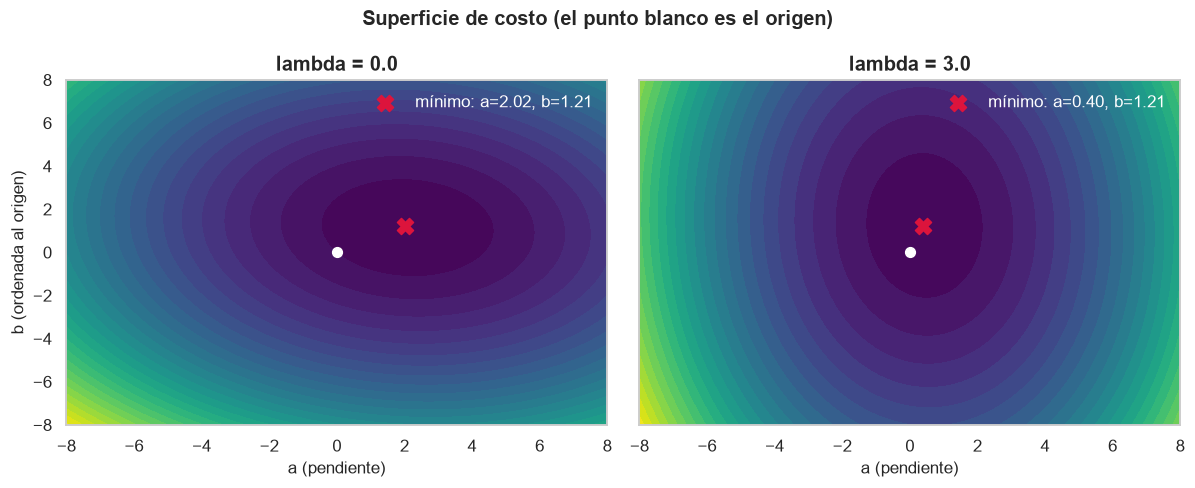

In [8]:
# Mismos datos que la celda 12 de la clase (mismo seed), pero graficado inline:
# la clase usa %matplotlib qt (celda 14), que abre una ventana externa.
np.random.seed(1)
n = 100
x = np.random.normal(0, 1, n)
pendiente_real, ordenada_real = 2, 1
y1d = pendiente_real * x + ordenada_real + np.random.normal(0, 1, n)

# a = pendiente, b = ordenada al origen. Penalizamos SOLO la pendiente.
def costo(A, B, lam=0.0):
    resid = A[..., None] * x + B[..., None] - y1d
    return np.mean(resid**2, axis=-1) + lam * A**2

rejilla = np.linspace(-8, 8, 100)
A, B = np.meshgrid(rejilla, rejilla)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, lam in zip(axes, [0.0, 3.0]):
    C = costo(A, B, lam)
    ax.contourf(A, B, C, levels=30, cmap="viridis")
    i, j = np.unravel_index(np.argmin(C), C.shape)
    ax.scatter(A[i, j], B[i, j], color="crimson", s=110, marker="X", zorder=5,
               label=f"mínimo: a={A[i, j]:.2f}, b={B[i, j]:.2f}")
    ax.scatter(0, 0, color="white", s=40, zorder=5)
    ax.set_title(f"lambda = {lam}")
    ax.set_xlabel("a (pendiente)")
    ax.legend(loc="upper right", labelcolor="white")
axes[0].set_ylabel("b (ordenada al origen)")
fig.suptitle("Superficie de costo (el punto blanco es el origen)", fontweight="bold")
plt.tight_layout()
plt.show()

A la izquierda, sin penalización: el mínimo cae cerca de $(2, 1)$, que son los
valores con los que generamos los datos (no exactamente, porque hay ruido y solo
100 observaciones). Las curvas de nivel son elipses casi circulares, porque con
un solo predictor normal estandarizado no hay ninguna dirección mal
condicionada.

A la derecha, con $\lambda = 3$: el mínimo se corrió fuerte hacia la izquierda,
hacia el origen, sobre el eje de la pendiente. La ordenada al origen quedó
exactamente donde estaba, porque a propósito no la penalizamos. Eso es el
encogimiento, dibujado.

Un detalle de escala, para que no compares peras con manzanas más adelante: acá
el error está **promediado** (dividido por $N = 100$) y la penalización no, así
que este $\lambda = 3$ pesa lo que pesaría un $\lambda = 300$ en la convención de
suma que usan la fórmula cerrada de §4 y `sklearn`. Es la misma trampa de §0.

### ⚠️ Confusión típica

Mirar este gráfico y pensar que los ejes son los datos. No lo son: los ejes son
los **parámetros**. Cada punto de este plano es un modelo completo, una recta
entera. El gráfico de los datos —el `plt.scatter(x, y)` de la celda 12— vive en
otro espacio, donde los ejes sí son $x$ e $y$. Confundir el espacio de datos con
el espacio de parámetros es el error número uno cuando aparecen las superficies
de costo, y va a volver en descenso por gradiente, en regularización y en todo
lo que venga después.

## 6. Dos predictores correlacionados: el valle

📓 celdas 16–21 · 📕 ESL §3.4

### La idea en criollo

Con un predictor el terreno era un pozo redondo y la bolita caía al fondo sin
dudar. Con dos predictores correlacionados el pozo se estira hasta convertirse
en un **valle largo y casi plano**: hay una dirección en la que moverse casi no
cambia el costo. La bolita rueda hasta el valle enseguida, pero después queda
vagando a lo largo, sin una razón fuerte para parar en un punto y no en el de al
lado.

> **Dónde se rompe la analogía.** Un valle geográfico tiene un fondo real y la
> bolita, con fricción, para en algún lado. Acá el fondo del valle tiene una
> pendiente pequeñísima pero **no nula** (mientras $\textbf{X}$ tenga rango
> completo), así que matemáticamente hay un mínimo único y exacto. El problema no
> es que no exista: es que está determinado por una diferencia de alturas tan
> chica que el ruido de una muestra distinta la mueve de lugar. Es la nube
> estirada de §2, vista desde arriba.

### Formalizándolo

La clase construye en la celda 17 dos predictores con correlación controlada:

$$x_2 = \rho\, x_1 + \sqrt{1-\rho^2}\,\varepsilon, \qquad \varepsilon \sim N(0,1)$$

Ese $\sqrt{1-\rho^2}$ no es decorativo: está puesto para que $x_2$ conserve
varianza 1. Con $x_1$ y $\varepsilon$ independientes de varianza 1,

$$Var(x_2) = \rho^2 Var(x_1) + (1-\rho^2)Var(\varepsilon) = \rho^2 + 1 - \rho^2 = 1$$

y la covarianza con $x_1$ da $Cov(x_1, x_2) = \rho$, así que la correlación es
exactamente $\rho$. Es la receta estándar para fabricar dos variables con
correlación a pedido sin cambiarles la escala.

La celda 19 define dos funciones de costo, una con penalización y otra sin, y
deja comentada la línea que las intercambia — la idea es que corras la clase dos
veces y compares las dos superficies. Eso es lo que hacemos abajo, en un solo
gráfico.

**Dónde está el valle, exactamente.** El costo, como función de
$(\beta_1,\beta_2)$, tiene curvas de nivel elípticas cuyos ejes son los
autovectores de $\textbf{X}^T\textbf{X}$. Con dos predictores estandarizados y
correlación $\rho$, esa matriz es aproximadamente $N\begin{pmatrix}1 & \rho\\ \rho & 1\end{pmatrix}$,
cuyos autovectores son $(1,1)/\sqrt2$ y $(1,-1)/\sqrt2$ con autovalores
$N(1+\rho)$ y $N(1-\rho)$. Con $\rho$ cerca de uno, el segundo autovalor se va a
cero: **la dirección $(1,-1)$ es el fondo del valle**, y es la dirección en la
que "le saco a $\beta_1$ y se lo doy a $\beta_2$".

In [9]:
# Datos de la celda 17 de la clase: dos predictores con correlación rho.
def datos_correlacionados(rho, n=100, seed=1):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(size=n)
    x2 = rho * x1 + np.sqrt(1 - rho**2) * rng.normal(size=n)
    y = 2 * x1 + 3 * x2 + rng.normal(size=n)
    return np.column_stack([x1, x2]), y

X07, y07 = datos_correlacionados(0.7)
X99, y99 = datos_correlacionados(0.99)
print(f"correlación empírica con rho=0.70 : {np.corrcoef(X07[:, 0], X07[:, 1])[0, 1]:.3f}")
print(f"correlación empírica con rho=0.99 : {np.corrcoef(X99[:, 0], X99[:, 1])[0, 1]:.3f}")
print(f"valores singulares  rho=0.70      : {np.round(np.linalg.svd(X07, compute_uv=False), 3)}")
print(f"valores singulares  rho=0.99      : {np.round(np.linalg.svd(X99, compute_uv=False), 3)}")

correlación empírica con rho=0.70 : 0.632
correlación empírica con rho=0.99 : 0.986
valores singulares  rho=0.70      : [11.359  5.345]
valores singulares  rho=0.99      : [12.048  0.995]


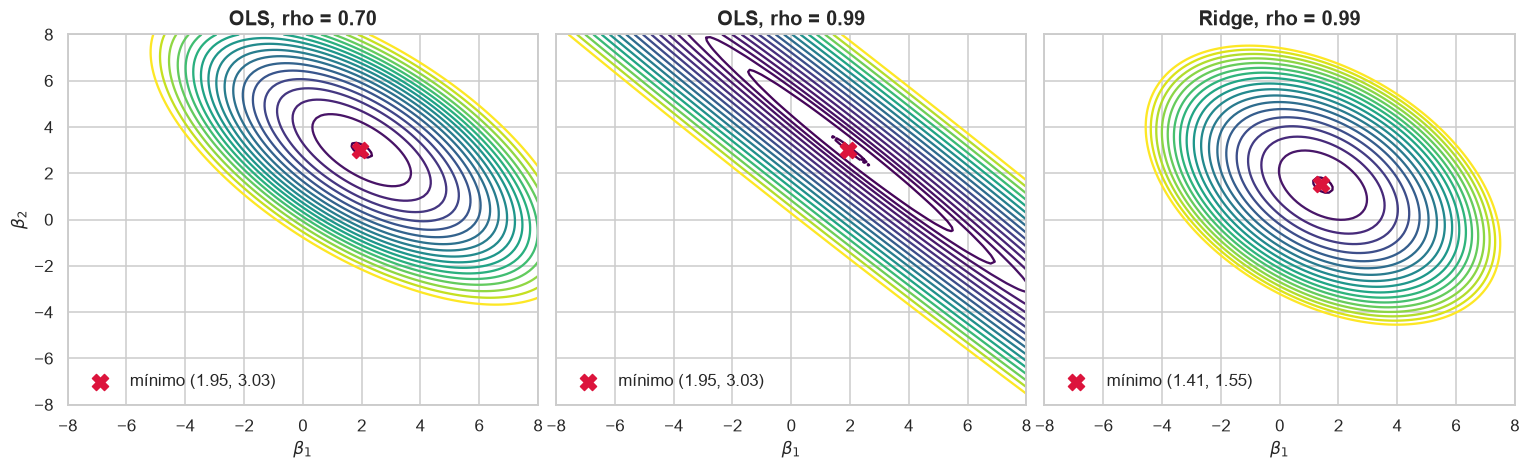

In [10]:
# La superficie de costo de las celdas 19-21, con y sin penalización.
def costo_2d(A, B, X, y, lam=0.0):
    resid = A[..., None] * X[:, 0] + B[..., None] * X[:, 1] - y
    return np.mean(resid**2, axis=-1) + lam * (A**2 + B**2)

rejilla = np.linspace(-8, 8, 120)
A, B = np.meshgrid(rejilla, rejilla)

paneles = [("OLS, rho = 0.70", X07, y07, 0.0),
           ("OLS, rho = 0.99", X99, y99, 0.0),
           ("Ridge, rho = 0.99", X99, y99, 1.0)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True)
for ax, (titulo, Xp, yp, lam) in zip(axes, paneles):
    C = costo_2d(A, B, Xp, yp, lam)
    ax.contour(A, B, C, levels=np.quantile(C, np.linspace(0.001, 0.4, 18)), cmap="viridis")
    i, j = np.unravel_index(np.argmin(C), C.shape)
    ax.scatter(A[i, j], B[i, j], color="crimson", s=110, marker="X", zorder=5,
               label=f"mínimo ({A[i, j]:.2f}, {B[i, j]:.2f})")
    ax.set_title(titulo)
    ax.set_xlabel(r"$\beta_1$")
    ax.legend(loc="lower left")
axes[0].set_ylabel(r"$\beta_2$")
plt.tight_layout()
plt.show()

De izquierda a derecha:

- **$\rho = 0{,}70$**: las elipses ya están inclinadas —el eje largo apunta en
  la dirección $(1,-1)$— pero todavía se cierran alrededor del mínimo.
- **$\rho = 0{,}99$**: las mismas curvas de nivel se estiraron hasta parecer
  rectas paralelas. Ese es el valle. Moverte a lo largo de él te cambia el costo
  poquísimo, y por eso el mínimo está mal determinado: es la traducción gráfica
  del $d_{min}$ chiquito de la celda anterior.
- **Ridge con $\rho = 0{,}99$**: sumarle $\lambda(\beta_1^2+\beta_2^2)$ —cuyas
  curvas de nivel son **círculos** centrados en el origen— vuelve a cerrar las
  elipses y a traer el mínimo hacia el centro. El valle se llenó. (Acá el
  encogimiento se ve muy grande para un $\lambda = 1$ porque, otra vez, el error
  está promediado: equivale a $\lambda = 100$ en la convención de suma, que es
  la que usa §7.)

Ese tercer panel es toda la clase en una imagen: la penalización aporta la
curvatura que a los datos les falta.

### ⚠️ Confusión típica

Hay dos trampas escondidas en el código de la clase, y las dos son fáciles de
arrastrar al ejercicio 2 sin darte cuenta.

La primera está en la celda 19: `cost_function_with_penalty` calcula
`np.mean(squared_error) + alpha * np.sum(beta**2)`. **Promedio** para el error,
**suma** para la penalización. Con $N=100$, poner `alpha=10` ahí equivale a un
$\lambda = 1000$ en la fórmula
$\|\textbf{y}-\textbf{X}\beta\|^2 + \lambda\|\beta\|^2$. No está mal —es una
convención—, pero si comparás ese `alpha` con el `alpha` de `sklearn.Ridge`
vas a estar comparando cosas que difieren en un factor $N$.

La segunda está en la celda 21: el punto rojo se dibuja con
`ax.scatter(beta_1, beta_1, 0, ...)`, con `beta_1` repetido. Debería ser
`beta_1, beta_2`. El gráfico sale igual de lindo y marca el lugar equivocado.
Cuando reuses código de la clase, chequeá los índices antes de creerle al
dibujo.

## 7. Los tres estimadores, lado a lado

📓 celdas 22–27 · 📕 ESL §3.2, §3.4

### La idea en criollo

Las celdas 22 a 27 son la parte práctica: calcular el mismo modelo de tres
maneras —`sklearn`, SVD a mano, ridge a mano— y mirar los números. Es el
momento de la clase en que las fórmulas se vuelven arrays.

### Formalizándolo

Las tres fórmulas que se ponen a prueba son las que ya derivamos:

$$\hat\beta^{ols} = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}, \qquad \hat\beta^{ols} = VD^{-1}U^T\textbf{y}, \qquad \hat\beta^{ridge} = (\textbf{X}^T\textbf{X} + \lambda I)^{-1}\textbf{X}^T\textbf{y}$$

Las dos primeras tienen que dar **lo mismo** (son la misma cuenta escrita
distinto, §1). La tercera tiene que dar algo **más chico en norma**, y la
diferencia tiene que crecer con $\lambda$.

Un detalle de la celda 23 que vale marcar: la clase ajusta con
`LinearRegression(fit_intercept=False)`. Sin ese argumento, `sklearn` agregaría
un intercepto y los coeficientes no coincidirían con la cuenta a mano, porque la
$\textbf{X}$ del ejemplo no tiene columna de unos. Los datos fueron generados sin
intercepto ($y = 2x_1 + 3x_2 + \varepsilon$), así que la elección es coherente
con el modelo.

In [11]:
# Las celdas 23, 25 y 27 de la clase, sobre el dataset con rho = 0.99.
from sklearn.linear_model import LinearRegression

lam = 1.0

# 1) Cuadrados mínimos con sklearn (celda 23). Sin intercepto: los datos no lo tienen.
beta_ols_sk = LinearRegression(fit_intercept=False).fit(X99, y99).coef_

# 2) Cuadrados mínimos vía SVD (celda 25).
U, D, Vh = np.linalg.svd(X99, full_matrices=False)
beta_ols_svd = Vh.T @ np.diag(1 / D) @ U.T @ y99

# 3) Ridge a mano (celda 27).
beta_ridge = np.linalg.solve(X99.T @ X99 + lam * np.eye(2), X99.T @ y99)

resumen = pd.DataFrame(
    [beta_ols_sk, beta_ols_svd, beta_ridge],
    index=["OLS (sklearn)", "OLS (SVD a mano)", f"Ridge (lambda={lam})"],
    columns=["beta_1", "beta_2"],
)
resumen["suma"] = resumen.sum(axis=1)
resumen["norma"] = np.linalg.norm(resumen[["beta_1", "beta_2"]], axis=1)
print(resumen.round(4).to_string())
print()
print("valores singulares:", np.round(D, 4), " -> beta real = (2, 3), suma = 5")

                    beta_1  beta_2    suma   norma
OLS (sklearn)       2.0156  2.9878  5.0034  3.6041
OLS (SVD a mano)    2.0156  2.9878  5.0034  3.6041
Ridge (lambda=1.0)  2.2425  2.7267  4.9692  3.5304

valores singulares: [12.048   0.9954]  -> beta real = (2, 3), suma = 5


Tres lecturas de esa tabla:

1. Las dos primeras filas coinciden hasta el último decimal. Confirmado: la SVD
   no es otro estimador, es otra forma de calcular el mismo.
2. En **esta** muestra OLS le acertó bastante bien a los dos coeficientes. No te
   confíes: la tabla de §2 dice que con $\rho = 0{,}99$ el desvío de cada
   coeficiente es de unos $0{,}7$, así que la puntería es de la muestra, no del
   método — otra muestra podría haber dado $(0{,}9\ ;\ 4{,}1)$ con el mismo
   ajuste. Ridge movió el reparto hacia un par más parejo y dejó la **suma**
   casi intacta, que es la cantidad que los datos sí determinan.
3. Ridge tiene norma menor que OLS. Eso no es una observación empírica de este
   caso: es una propiedad del método. $\hat\beta^{ridge}$ minimiza
   $RSS + \lambda\|\beta\|^2$ y $\hat\beta^{ols}$ minimiza solo $RSS$, así que
   $\|\hat\beta^{ridge}\| \le \|\hat\beta^{ols}\|$ siempre.

#### 🏭 Así se hace en la industria

In [12]:
from sklearn.linear_model import Ridge

# sklearn minimiza ||y - X b||^2 + alpha ||b||^2 (suma, no promedio), así que
# alpha se corresponde uno a uno con nuestro lambda.
beta_ridge_sk = Ridge(alpha=lam, fit_intercept=False).fit(X99, y99).coef_

print("Ridge a mano   :", np.round(beta_ridge, 6))
print("Ridge sklearn  :", np.round(beta_ridge_sk, 6))
print("¿coinciden?    :", np.allclose(beta_ridge, beta_ridge_sk))

Ridge a mano   : [2.242525 2.726666]
Ridge sklearn  : [2.242525 2.726666]
¿coinciden?    : True


Idénticos, y no por casualidad: `Ridge` resuelve exactamente el mismo sistema
(con solvers más cuidadosos que un `solve` directo cuando la matriz es grande o
fea). En producción se usa esta versión, dentro de un `Pipeline` con
`StandardScaler` y con el `alpha` elegido por validación cruzada — ese es,
literalmente, el enunciado del ejercicio 2.

### ⚠️ Confusión típica

Que `Ridge(alpha=1)` de `sklearn` sea lo mismo que "penalizar con $\lambda=1$"
depende de cómo esté escrito **tu** costo. `sklearn` usa la convención de suma
en ambos términos, igual que la clase en la parte teórica; la
`cost_function_with_penalty` de la celda 19 usa promedio en el error, y ahí el
mismo número significa otra cosa. Antes de comparar valores de regularización
entre dos implementaciones, comparás las fórmulas de costo. Siempre.

## 8. Ridge visto con la SVD: encoger, no truncar

📓 celdas 28–32 · 📕 ESL §3.4 · 📘 Bishop §3.1.4

### La idea en criollo

Esta es la sección donde ridge deja de ser un truco algebraico y se vuelve algo
que podés explicar en una frase. La SVD parte el problema en direcciones
independientes —cada una con su valor singular $d_j$, que mide cuánta
información trae esa dirección— y resulta que ridge trata a cada dirección por
separado, como un **ecualizador** de audio que le baja el volumen a cada banda
según cuánta señal traiga. Las
direcciones con mucha señal quedan casi intactas; las direcciones con poca señal
quedan casi apagadas.

> **Dónde se rompe la analogía.** Un ecualizador tiene una perilla por banda y
> vos las movés una por una. Acá tenés **una sola perilla**, $\lambda$, y la
> curva de atenuación queda determinada por ella y por los $d_j$ de tus datos.
> No podés decidir atenuar la tercera dirección y no la cuarta: el método decide
> por vos, en función de $d_j$.

### Formalizándolo

Partimos de la solución de ridge y reemplazamos $\textbf{X} = UDV^T$ paso a paso,
tal como hace la celda 28. Primero el término de adentro:

$$\textbf{X}^T\textbf{X} + \lambda I = VDU^TUDV^T + \lambda I = VD^2V^T + \lambda I$$

(otra vez $U^TU = I$). Ahora el paso que la clase escribe de un saque y conviene
desarmar: queremos meter el $\lambda I$ adentro del sándwich $V(\cdot)V^T$. Se
puede porque $V$ es ortogonal, así que $VV^T = I$ y entonces
$\lambda I = \lambda VV^T = V(\lambda I)V^T$:

$$VD^2V^T + V(\lambda I)V^T = V(D^2 + \lambda I)V^T$$

Falta invertir eso. La clase dice "*basta invertir el término del medio*" e
invita a hacer la cuenta para convencerse. Hagámosla, que son dos líneas.
Proponemos $V(D^2+\lambda I)^{-1}V^T$ como candidato a inversa y multiplicamos:

$$V(D^2+\lambda I)^{-1}V^T \cdot V(D^2+\lambda I)V^T = V(D^2+\lambda I)^{-1}(D^2+\lambda I)V^T = VV^T = I$$

donde usamos $V^TV = I$ en el medio y $VV^T = I$ al final. Como da la identidad,
el candidato **es** la inversa. Y $(D^2+\lambda I)^{-1}$ es fácil de escribir
porque $D^2 + \lambda I$ es diagonal —tiene $d_j^2 + \lambda$ en la diagonal— y
la inversa de una matriz diagonal se obtiene invirtiendo cada elemento:
$1/(d_j^2+\lambda)$.

Armamos todo:

$$\hat\beta^{ridge} = V(D^2+\lambda I)^{-1}V^T \cdot VDU^T\textbf{y} = V(D^2+\lambda I)^{-1}DU^T\textbf{y}$$

cancelando $V^TV = I$ en el medio. Y ahora la comparación de la celda 29, que es
el corazón de todo:

$$\hat\beta^{ols} = V\,D^{-1}\,U^T\textbf{y} \qquad\text{vs.}\qquad \hat\beta^{ridge} = V\,(D^2+\lambda I)^{-1}D\,U^T\textbf{y}$$

**Todo es igual salvo la matriz del medio.** Las dos son diagonales. En OLS el
elemento $j$ vale $1/d_j$; en ridge vale $d_j/(d_j^2+\lambda)$. El cociente
entre ambas es el **factor de encogimiento**:

$$\frac{d_j/(d_j^2+\lambda)}{1/d_j} = \frac{d_j^2}{d_j^2+\lambda} \le 1$$

que es menor o igual que 1 porque $d_j^2$ y $\lambda$ son no negativos, y
sumarle algo no negativo al denominador solo puede achicar la fracción. Con
$\lambda = 0$ vale exactamente 1 —recuperás OLS—; con $\lambda > 0$ es
estrictamente menor.

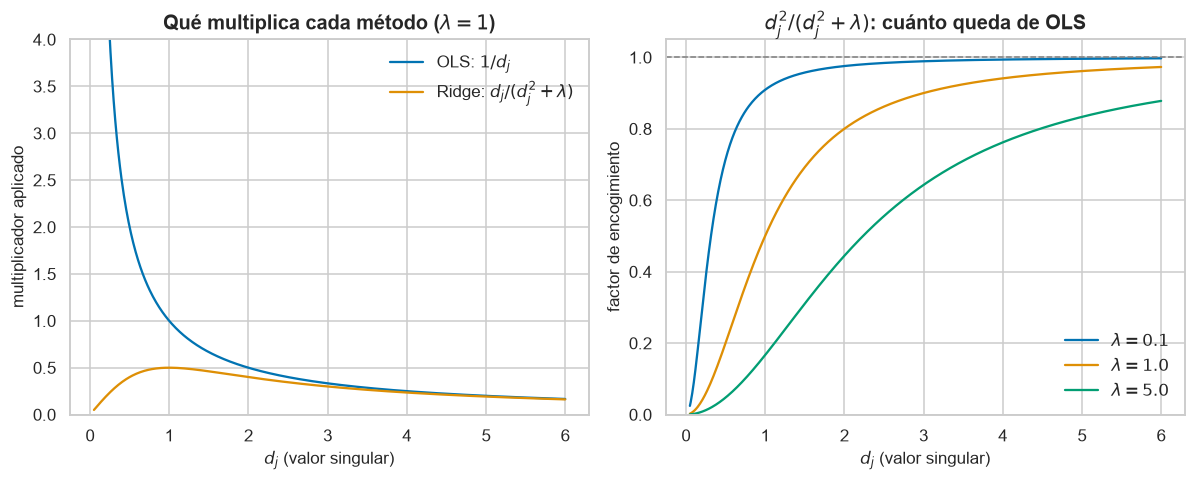

d_j =   0.1: queda el   0.99% de lo que haría OLS (lambda=1)
d_j =   0.5: queda el  20.00% de lo que haría OLS (lambda=1)
d_j =   1.0: queda el  50.00% de lo que haría OLS (lambda=1)
d_j =   3.0: queda el  90.00% de lo que haría OLS (lambda=1)
d_j =  10.0: queda el  99.01% de lo que haría OLS (lambda=1)


In [13]:
# La comparación de la celda 31, en dos paneles.
d = np.linspace(0.05, 6, 600)     # arrancamos en 0.05: 1/d explota en 0
lam_ = 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(d, 1 / d, label=r"OLS: $1/d_j$")
axes[0].plot(d, d / (d**2 + lam_), label=r"Ridge: $d_j/(d_j^2+\lambda)$")
axes[0].set_ylim(0, 4)
axes[0].set_xlabel(r"$d_j$ (valor singular)")
axes[0].set_ylabel("multiplicador aplicado")
axes[0].set_title(r"Qué multiplica cada método ($\lambda=1$)")
axes[0].legend()

for l in [0.1, 1.0, 5.0]:
    axes[1].plot(d, d**2 / (d**2 + l), label=fr"$\lambda={l}$")
axes[1].axhline(1, color="grey", lw=1, ls="--")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel(r"$d_j$ (valor singular)")
axes[1].set_ylabel("factor de encogimiento")
axes[1].set_title(r"$d_j^2/(d_j^2+\lambda)$: cuánto queda de OLS")
axes[1].legend()

plt.tight_layout()
plt.show()

for dj in [0.1, 0.5, 1.0, 3.0, 10.0]:
    print(f"d_j = {dj:>5}: queda el {100 * dj**2 / (dj**2 + 1):6.2f}% de lo que haría OLS (lambda=1)")

### ❓ La pregunta que quedó abierta

La clase pregunta dos veces "*¿qué implica?*" (celdas 29 y 32) y solo contesta
media línea: "*se parece a recortar los valores singulares, pero de manera más
suave*". Desarmemos esa frase, que dice más de lo que parece.

**Primero, qué implica el factor $d_j^2/(d_j^2+\lambda)$.** Miralo en los dos
extremos, que es donde se entiende:

- Si $d_j \gg \sqrt{\lambda}$ (dirección con mucha señal), el factor es
  $\approx 1$: ridge deja esa dirección prácticamente como la dejaba OLS.
- Si $d_j \ll \sqrt{\lambda}$ (dirección casi degenerada, la peligrosa), el
  factor es $\approx d_j^2/\lambda \approx 0$: ridge la apaga.

La última línea de la salida de arriba lo pone en números: con $\lambda = 1$, una
dirección con $d_j = 10$ conserva el 99 % de lo que hacía OLS, y una con
$d_j = 0{,}1$ conserva el 1 %. **La regularización no encoge todo por igual:
encoge selectivamente, y le pega justo a las direcciones que causaban la
inestabilidad de §2.** Eso es lo que la vuelve una respuesta a la
multicolinealidad y no un simple "achicá todo un poco".

Mirá también el panel de la izquierda cerca del cero. La curva de OLS se va a
infinito —ahí está la división por $d_{min}$ que arruina todo—, mientras que la
de ridge sube, alcanza un máximo y **vuelve a bajar hasta cero**. Ridge está
acotado: por chico que sea $d_j$, el multiplicador nunca supera
$1/(2\sqrt\lambda)$.

**Segundo, qué quiere decir "recortar los valores singulares".** La alternativa
cruda a ridge es una regla de todo o nada: quedarse con las direcciones de
$d_j$ grande y tirar las de $d_j$ chico (poner el multiplicador en cero). Esa
regla existe, se llama regresión por componentes principales, y su curva de
encogimiento sería un escalón: 1 hasta cierto punto, 0 después. Comparala con
las curvas del panel derecho: ridge hace la misma transición, pero **continua y
gradual**, sin un corte arbitrario. Eso es "más suave". Y trae una ventaja
concreta: como es continua en $\lambda$, un cambio chico del hiperparámetro
produce un cambio chico del modelo, mientras que en la versión con corte una
componente entra o sale de golpe.

### ⚠️ Confusión típica

Leer $\hat\beta^{ridge} = V(D^2+\lambda I)^{-1}DU^T\textbf{y}$ y pensar que cada
coeficiente $\hat\beta_j$ se multiplica por $d_j^2/(d_j^2+\lambda)$. **No.** El
encogimiento pasa en la base de las **columnas de $V$** (las direcciones
principales), no en la base de las variables originales. Al volver a la base
original —el $V$ de la izquierda— cada coeficiente termina siendo una mezcla de
direcciones encogidas en distinta medida. Por eso en el camino de coeficientes
de §3 las tres curvas bajan a ritmos distintos y ninguna es una simple escala
de la otra.

Si querés ponerle un número al encogimiento total, existe: son los **grados de
libertad efectivos** $\text{df}(\lambda) = \sum_j d_j^2/(d_j^2+\lambda)$, la
suma de los factores del panel derecho. Vale $p$ cuando $\lambda = 0$ y tiende a
cero cuando $\lambda$ crece. Está en 📕 ESL §3.4.1, que es donde sigue este hilo.

## 🧵 El hilo conductor

Esta clase es la respuesta a una pregunta que quedó abierta en la anterior. La
clase 2 cerró cuadrados mínimos con una advertencia al pasar: todo esto vale
"*mientras $\textbf{X}$ tenga rango completo*". La clase 3 le dio a esa
advertencia una forma cuantitativa con la SVD: el rango es la cantidad de
valores singulares no nulos, y $\hat\beta = VD^{-1}U^T\textbf{y}$ divide por
ellos. La clase de hoy toma esa división por $d_j$ y la arregla.

El recorrido tiene una sola idea repetida en tres idiomas. En el idioma
**algebraico**, sumarle $\lambda I$ a $\textbf{X}^T\textbf{X}$ le corre todos los
autovalores $\lambda$ hacia arriba y la vuelve invertible siempre. En el idioma
**geométrico**, sumarle un paraboloide circular al costo le devuelve curvatura al
valle plano que fabrica la multicolinealidad, y el mínimo deja de estar mal
determinado. En el idioma de la **SVD**, cambiar $1/d_j$ por
$d_j/(d_j^2+\lambda)$ apaga selectivamente las direcciones con poca señal. Los
tres son la misma cuenta; entender que son la misma cuenta es lo que hay que
llevarse de la clase.

Hacia adelante quedan tres hilos sueltos, y los tres están marcados en la propia
clase. El primero es **cómo se elige $\lambda$**: hoy lo tratamos como un número
que aparece dado, y en la práctica sale de validación cruzada (📕 ESL §7.10).
El segundo es **por qué conviene sesgar a propósito**: la celda 5 nombra
Gauss–Markov y lo deja pendiente hasta ver el compromiso sesgo–varianza
(📕 ESL §2.9 y §7.2), que es donde ridge deja de parecer un parche numérico y
pasa a ser una decisión estadística. El tercero son **las otras
penalizaciones**: el Lasso, que con $\sum_j|\beta_j|$ sí manda coeficientes a
cero exacto y hace selección de variables, y Elastic Net, que combina las dos
(📕 ESL §3.4.2–§3.4.3). Los tres papers de la portada de la clase son,
justamente, esas tres paradas.

## ✅ Autoevaluación

**1.** ¿Qué modelo obtenés con $\lambda = 0$? ¿Y cuando $\lambda \to \infty$?

<details><summary>Respuesta</summary>

Con $\lambda = 0$ la penalización desaparece del costo y te queda
$\arg\min \|\textbf{y}-\textbf{X}\beta\|^2$: cuadrados mínimos exacto, con toda
su fórmula y todos sus problemas si $\textbf{X}$ está mal condicionada.

Con $\lambda \to \infty$ el término $\lambda\|\beta\|^2$ domina el costo, y la
única manera de que no explote es $\beta \to 0$. Todos los coeficientes tienden
a cero (sin llegar nunca) y el modelo predice la constante $\bar y$ — el
intercepto, que no está penalizado, sobrevive. Es el modelo más simple posible:
la media de las respuestas, sin mirar ningún predictor.

</details>

**2.** Mostrá que $\textbf{X}^T\textbf{X} + \lambda I$ es invertible para
cualquier $\lambda > 0$, sin suponer nada sobre el rango de $\textbf{X}$.

<details><summary>Respuesta</summary>

Tomá cualquier $v \neq 0$ y calculá la forma cuadrática:

$$v^T(\textbf{X}^T\textbf{X} + \lambda I)v = v^T\textbf{X}^T\textbf{X}v + \lambda v^Tv = \|\textbf{X}v\|^2 + \lambda\|v\|^2$$

El primer sumando es $\ge 0$ por ser una norma al cuadrado, y el segundo es
$> 0$ porque $\lambda > 0$ y $v \neq 0$. La suma es estrictamente positiva, así
que la matriz es definida positiva y por lo tanto no tiene el 0 como autovalor:
es invertible.

Vía SVD el argumento es el mismo en otra ropa: los autovalores de
$\textbf{X}^T\textbf{X}$ son los $d_j^2 \ge 0$, y los de
$\textbf{X}^T\textbf{X}+\lambda I$ son $d_j^2 + \lambda \ge \lambda > 0$.

</details>

**3.** Multiplicás una columna de $\textbf{X}$ por 100. ¿Cambian las
predicciones de OLS? ¿Y las de ridge?

<details><summary>Respuesta</summary>

OLS: las predicciones **no** cambian. El coeficiente de esa columna se divide
por 100 y el producto $x_j\beta_j$ queda igual. Cuadrados mínimos es equivariante
ante reescalados de las columnas, porque el espacio generado por las columnas de
$\textbf{X}$ —sobre el que se proyecta $\textbf{y}$— es exactamente el mismo.

Ridge: **sí** cambian. La penalización $\sum_j\beta_j^2$ no es invariante: el
coeficiente nuevo es 100 veces más chico, así que aporta $10^4$ veces menos a la
penalización, y con el mismo $\lambda$ esa variable pasa a estar mucho menos
castigada que antes. Distinta penalización, distinto mínimo, distintas
predicciones. Por eso se estandariza.

</details>

**4.** Con $\lambda = 4$, ¿qué fracción del valor de OLS conserva ridge en una
dirección con $d_j = 2$? ¿Y en una con $d_j = 0{,}2$?

<details><summary>Respuesta</summary>

El factor de encogimiento es $d_j^2/(d_j^2+\lambda)$.

Con $d_j = 2$: $4/(4+4) = 0{,}5$. Conserva la mitad.

Con $d_j = 0{,}2$: $0{,}04/(0{,}04+4) = 0{,}0099$, menos del 1 %. Prácticamente
apagada.

La misma perilla $\lambda$ produjo un recorte moderado en una dirección y un
apagado casi total en la otra. Ese es el punto de §8: el encogimiento es
selectivo, no uniforme.

</details>

**5.** ¿Ridge sirve para seleccionar variables?

<details><summary>Respuesta</summary>

No. Ridge achica coeficientes hacia cero pero no los pone en cero: la solución
$(\textbf{X}^T\textbf{X}+\lambda I)^{-1}\textbf{X}^T\textbf{y}$ es una función
continua de $\lambda$ y, salvo casos degenerados, todas las componentes quedan
distintas de cero para cualquier $\lambda$ finito. Te da un modelo con los $p$
predictores, todos con peso chico.

El que sí selecciona es el Lasso: la penalización $\sum_j|\beta_j|$ tiene una
esquina en el cero que hace que la solución óptima caiga exactamente ahí para
muchos coeficientes (📕 ESL §3.4.2). Y la selección de subconjuntos del
ejercicio 1 hace lo mismo de manera discreta, probando combinaciones
(📕 ESL §3.3).

</details>

**6.** ¿Qué pasa si aplicás ridge **sin** centrar los datos y penalizando también
a $\beta_0$?

<details><summary>Respuesta</summary>

Le estarías cobrando peaje al intercepto, que es el que absorbe el nivel general
de $\textbf{y}$. Consecuencia concreta: el modelo deja de ser invariante ante
corrimientos. Si a todas las respuestas les sumás 10 —cambiás de unidad, por
ejemplo de grados Celsius a una escala corrida—, el $\hat\beta_0$ óptimo debería
subir 10 y nada más; con $\beta_0$ penalizado, el optimizador prefiere no
pagarlo entero y compensa distorsionando los **otros** coeficientes. El modelo
depende de dónde pusiste el cero de tus variables, que es una decisión sin
contenido.

Por eso la formulación explícita de la celda 6 arranca la sumatoria de la
penalización en $j=1$, y por eso en la práctica se centran $\textbf{y}$ y las
columnas de $\textbf{X}$, se ajusta sin intercepto y se recupera
$\hat\beta_0 = \bar y$.

</details>

**7.** Tenés $N = 30$ observaciones y $p = 200$ predictores. ¿Existe
$\hat\beta^{ols}$? ¿Existe $\hat\beta^{ridge}$?

<details><summary>Respuesta</summary>

$\hat\beta^{ols}$ no está definido de manera única: el rango de $\textbf{X}$ está
acotado por $\min(N, p) = 30$, así que $\textbf{X}^T\textbf{X}$ (de $200\times200$)
tiene a lo sumo rango 30 y es singular. Hay un subespacio de dimensión al menos
170 de soluciones que ajustan los 30 puntos exactamente, todas con $RSS = 0$.

$\hat\beta^{ridge}$ sí existe y es único para cualquier $\lambda > 0$, por el
ejercicio 2 de esta lista: la invertibilidad de
$\textbf{X}^T\textbf{X}+\lambda I$ no le pide nada al rango de $\textbf{X}$. Esta
es la razón de fondo por la que la regularización es obligatoria en problemas
con $p > N$ —genómica, texto, imágenes—, no un refinamiento opcional.

</details>

**8.** Calculá $E[\hat\beta^{ridge}]$ suponiendo el modelo
$\textbf{y} = \textbf{X}\beta + \varepsilon$ con $E[\varepsilon] = 0$ y
$\textbf{X}$ fija. ¿Es insesgado?

<details><summary>Respuesta</summary>

Llamemos $A = (\textbf{X}^T\textbf{X}+\lambda I)^{-1}\textbf{X}^T$, que es una
matriz de constantes (no depende de $\textbf{y}$). Entonces
$\hat\beta^{ridge} = A\textbf{y}$ y, por linealidad de la esperanza:

$$E[\hat\beta^{ridge}] = A\,E[\textbf{y}] = A\textbf{X}\beta = (\textbf{X}^T\textbf{X}+\lambda I)^{-1}\textbf{X}^T\textbf{X}\beta$$

Con $\lambda = 0$ eso se simplifica a $\beta$: OLS es insesgado. Con
$\lambda > 0$, la matriz $(\textbf{X}^T\textbf{X}+\lambda I)^{-1}\textbf{X}^T\textbf{X}$
no es la identidad —sus autovalores son $d_j^2/(d_j^2+\lambda) < 1$, los mismos
factores de encogimiento de §8—, así que $E[\hat\beta^{ridge}] \neq \beta$:
**ridge es sesgado**, y el sesgo apunta sistemáticamente hacia el cero.

Eso no lo descalifica: lo saca de la clase de estimadores lineales insesgados
donde Gauss–Markov corona a OLS, y lo habilita a tener menor error cuadrático
medio total, porque la caída de varianza puede más que el sesgo que agregás.
Esa cuenta es el compromiso sesgo–varianza, en 📕 ESL §2.9 y §7.2.

</details>

## 🎯 Centros para los ejercicios

### Ejercicio 1 — Subset selection

- **De qué va realmente:** ubicar a ridge dentro de una familia más grande. Hay
  dos estrategias distintas para pelear contra el sobreajuste y la
  multicolinealidad: **elegir** un subconjunto de variables y tirar el resto
  (discreta, combinatoria) o **encoger** todos los coeficientes sin tirar
  ninguna (continua, que es ridge). El ejercicio te pide entender la primera
  para que la segunda tenga con qué contrastarse.
- **Por dónde arrancar:** por 📕 ESL §3.3, que es donde está el tema. Anotá tres
  cosas mientras leés: cuántos modelos hay que probar con $p$ predictores si
  querés mirarlos todos, qué hacen *forward stepwise* y *backward stepwise* para
  no probarlos todos, y con qué criterio se compara entre modelos de distinto
  tamaño (por qué el $RSS$ solo no alcanza).
- **Con qué chequear:** si podés responder "¿por qué *best subset* se vuelve
  impracticable con $p = 40$?" con un número concreto, y "¿en qué se diferencia
  el resultado de subset selection del de ridge, mirando el vector
  $\hat\beta$?", el ejercicio está entendido. La figura del camino de
  coeficientes de §3 te da la mitad de la segunda respuesta.
- **⚠️ Dónde te vas a trabar:** en confundir *subset selection* con mirar los
  $p$-valores del ajuste completo y quedarte con los significativos. No es lo
  mismo, y con predictores correlacionados puede dar resultados muy distintos —
  pensá por qué, usando lo que viste en §2 sobre qué le pasa a los coeficientes
  individuales cuando dos variables están correlacionadas.

### Ejercicio 2 — Ridge sobre Prostate Cancer

- **De qué va realmente:** reproducir un resultado publicado, que es el único
  chequeo honesto de que tu implementación hace lo que creés. Y después la
  pregunta que la clase deja abierta: $\lambda$ no sale de los datos de
  entrenamiento (el que mejor los ajusta es siempre $\lambda = 0$), así que
  necesitás un mecanismo aparte para elegirlo.
- **Por dónde arrancar:** por los datos, no por el modelo. El archivo está en
  `src/datasets/prostate.data` y trae una columna `train` que marca la partición
  que usa el libro; respetala. Estandarizá los predictores **con la media y el
  desvío del conjunto de entrenamiento** y centrá $\textbf{y}$; recién ahí
  escribí el `np.linalg.solve` de dos líneas de §4. Empezá con un $\lambda$
  cualquiera y andá viendo cómo se mueven los coeficientes antes de buscar el
  bueno.
- **Con qué chequear:** con $\lambda = 0$ tus coeficientes tienen que reproducir
  la columna de mínimos cuadrados de la 📕 Tabla 3.2 de ESL. Si eso no da, el
  problema está en el preprocesamiento o en la partición, no en ridge — arreglá
  eso antes de seguir. Después compará contra `sklearn.linear_model.Ridge` con
  el mismo `alpha` y los mismos datos ya estandarizados: tiene que dar idéntico
  (§7). Para la Tabla 3.3, acordate de que el libro reporta los coeficientes en
  la escala estandarizada.
- **⚠️ Dónde te vas a trabar:** en dos lugares. Uno, en el estandarizado dentro
  de la validación cruzada: si escalás usando todo el dataset antes de partir en
  folds, estás filtrando información del test y tu error de validación va a dar
  optimista. Dos, en la pregunta "¿qué nivel de regularización se utilizó?": el
  libro no lo dice como un número que se lee, se deduce del resultado — pensá
  qué cantidad de la Tabla 3.3 podés calcular vos para cada $\lambda$ de una
  grilla y comparar.

### Ejercicio 3 — Dos atributos idénticos: cómo reparte Ridge

- **De qué va realmente:** demostrar con lápiz lo que viste dibujado en §6. El
  valle plano de las curvas de nivel y la nube estirada de §2 son este ejercicio
  llevado al extremo: cuando $x_2 = x_1$ exactamente, el valle es *perfectamente*
  plano y cuadrados mínimos no tiene nada que decir sobre el reparto. Ridge sí.
- **Por dónde arrancar:** por la primera parte, que es pura escritura. Escribí
  $\textbf{X}\beta$ con $\textbf{X} = [x_1\ \ x_1]$ y sacá $x_1$ de factor común:
  vas a ver qué combinación de $\beta_1$ y $\beta_2$ aparece, y con eso la
  conclusión sobre unicidad sale sola (acordate: si $\hat\beta$ es solución y
  $\textbf{X}v = 0$, entonces $\hat\beta + cv$ también lo es — ¿cuál es ese $v$
  acá?). Para la segunda parte, un problema de minimización con una restricción
  de igualdad: o sustituís $\beta_2 = c - \beta_1$ y derivás en una sola
  variable, o usás multiplicadores de Lagrange (los viste en la clase 3).
- **Con qué chequear:** armá numéricamente `X = np.column_stack([x1, x1])`,
  resolvé ridge con la fórmula de §4 para varios $\lambda$, y comparás el
  reparto que devuelve la máquina con el que te dio la cuenta. Tienen que
  coincidir para todo $\lambda > 0$. Chequeá también que la suma
  $\hat\beta_1+\hat\beta_2$ que te da ridge se acerque a la pendiente de la
  regresión simple de $\textbf{y}$ sobre $x_1$ cuando $\lambda$ es chico.
- **⚠️ Dónde te vas a trabar:** en la primera parte, si intentás atacarla con la
  fórmula $(\textbf{X}^T\textbf{X})^{-1}$ — no existe, ese es justamente el
  punto. Trabajá con la expresión del error, no con la solución. En la segunda,
  cuidado con querer minimizar el costo completo: el enunciado te pide minimizar
  **solo la penalización** con la suma ya fijada en $c$, porque el término de
  error, por lo que probaste en la primera parte, no distingue entre repartos.